# **Important Rules and Restrictions**

Use of the following libraries is strictly prohibited:

- NLTK  
- spaCy  
- HuggingFace Tokenizers  
- SentencePiece  
- Urduhack  
- Stanza  
- Polyglot  
- Gensim Language Models  
- sklearn CountVectorizer / TfidfVectorizer  

Violation will result in zero marks.

### **Allowed Libraries**
Students may use:

- Python Standard Functions 
- Regex  
- NumPy  
- Pandas  
- BeautifulSoup / Requests / Scrapy / Selenium (For use of Scraping only)  
- Matplotlib  

## **Part 1: BBC Urdu Dataset Collection and Preprocessing**
In this part, BBC Urdu news articles are collected and prepared into a clean dataset using normalization and custom preprocessing tools. The output of this part will be reused directly in Part 2.

News articles must be scraped from:
https://www.bbc.com/urdu

Students must scrape:
- Minimum: 200 articles
- Maximum: 300 articles

Each article must be complete and properly structured.

Article metadata must be stored in a JSON file with the following constraints:
- Each article must be numbered
- Article numbers must be unique
- Article numbers must match TXT files
- Article body must not be included

### ***Format Example***
```json
{
  "1": {
    "title": "پاکستان میں مہنگائی کی شرح میں اضافہ",
    "publish_date": "2024-01-15"
  },
  "2": {
    "title": "کراچی میں بارش کے بعد صورتحال",
    "publish_date": "2024-02-02"
  }
}

In [1]:
import requests
from bs4 import BeautifulSoup
import json
import time
from urllib.parse import urljoin
import re
import os

In [2]:
# Clean previous outputs (keep it simple; assume files exist when needed)
for fp in [
    'raw.txt', 'cleaned.txt', 'metadata.json',
    'stemmed.txt', 'tokenized.txt', 'lemmatized.txt'
]:
    if os.path.exists(fp):
        os.remove(fp)
print('Old output files removed (if present).')


Old output files removed (if present).


In [3]:
def extract_article_fields(soup):
    """Extract title, publish_date, and RTL body paragraphs from a BBC Urdu article page."""
    title = ""
    publish_date = ""

    next_data = soup.find('script', id='__NEXT_DATA__')
    if next_data and next_data.string:
        try:
            data = json.loads(next_data.string)
            page_data = data['props']['pageProps']['pageData']
            analytics = page_data['metadata']['atiAnalytics']
            title = analytics.get('pageTitle', '')
            publish_date = analytics.get('timePublished', '')
        except Exception:
            pass

    main = soup.find('main', role='main') or soup
    paragraphs = main.find_all('p', dir='rtl')
    body_text = "\n".join(p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True))
    return title.strip() or "No Title", publish_date.strip() or "Unknown Date", body_text.strip()


def save_raw_txt(raw_articles, output_path='raw.txt'):
    with open(output_path, 'w', encoding='utf-8') as f:
        for a in raw_articles:
            f.write(f"[{a['article_number']}]\n{a['body']}\n\n")


def save_metadata_json(metadata_records, output_path='metadata.json'):
    # Keep schema aligned with assignment example: no body text.
    obj = {
        str(r['article_number']): {
            'title': r['title'],
            'publish_date': r['publish_date'],
        }
        for r in metadata_records
    }
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, ensure_ascii=False, indent=4)


def scrape_bbc_urdu(target_count=300, min_body_chars=300, sleep_s=0.4):
    base_url = "https://www.bbc.com"
    start_pages = [
        "https://www.bbc.com/urdu",
        "https://www.bbc.com/urdu/topics/cjgn7n9zzq7t",
        "https://www.bbc.com/urdu/topics/cl8l9mveql2t",
        "https://www.bbc.com/urdu/topics/cw57v2pmll9t",
        "https://www.bbc.com/urdu/topics/c340q0p2585t",
        "https://www.bbc.com/urdu/topics/ckdxnx900n5t",
        "https://www.bbc.com/urdu/topics/c40379e2ymxt",
    ]

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    }

    session = requests.Session()
    queue = list(start_pages)
    visited = set()

    raw_articles = []
    metadata_records = []

    print(f"Crawling BBC Urdu for up to {target_count} articles...")

    while queue and len(raw_articles) < target_count:
        url = queue.pop(0)
        if url in visited:
            continue
        visited.add(url)

        r = session.get(url, headers=headers, timeout=15)
        soup = BeautifulSoup(r.text, 'html.parser')

        # Discover more article links
        for a in soup.find_all('a', href=True):
            href = a['href']
            if '/urdu/articles/' in href:
                full = urljoin(base_url, href)
                clean = full.split('?')[0].split('#')[0]
                if clean not in visited:
                    queue.append(clean)

        # If this is an article page, extract it
        if '/urdu/articles/' in url:
            title, publish_date, body = extract_article_fields(soup)
            if len(body) >= min_body_chars:
                n = len(raw_articles) + 1
                raw_articles.append({'article_number': n, 'body': body})
                metadata_records.append({
                    'article_number': n,
                    'title': title,
                    'publish_date': publish_date,
                })
                if n % 10 == 0 or n == 1:
                    print(f"  scraped {n}/{target_count}")

        time.sleep(sleep_s)

    save_raw_txt(raw_articles, 'raw.txt')
    save_metadata_json(metadata_records, 'metadata.json')

    print(f"Saved {len(raw_articles)} articles to raw.txt")
    print(f"Saved metadata for {len(metadata_records)} articles to metadata.json")

    return {
        'count': len(raw_articles),
        'metadata': metadata_records,
        'raw_articles': raw_articles,
    }


In [ ]:
scrape_results = scrape_bbc_urdu(target_count=300)

Crawling BBC Urdu for up to 300 articles...
  scraped 1/300
  scraped 10/300
  scraped 20/300
  scraped 30/300
  scraped 40/300
  scraped 50/300


### ***raw.txt File***
This file must contain:
- Raw scraped article content
- No cleaning or normalization
- One article per block
- Each article must start with its article number

### ***Example***
```json
[1]
یہ خبر بی بی سی اردو سے حاصل کی گئی ہے...

[2]
کراچی میں بارش کے بعد صورتحال خراب ہو گئی...

In [5]:
# raw.txt is already written by scrape_bbc_urdu().
# (If you loaded scrape_results from a previous run, you can rewrite raw.txt from memory.)
if 'scrape_results' in globals() and isinstance(scrape_results, dict):
    save_raw_txt(scrape_results['raw_articles'], 'raw.txt')

print('Preview (first 20 lines of raw.txt):')
with open('raw.txt', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 20:
            break
        print(line.rstrip())


Preview (first 20 lines of raw.txt):
[1]
پاکستان تحریکِ انصاف (پی ٹی آئی) کے بانی اور سابق وزیرِ اعظم عمران خان کی آنکھ کے علاج کے معاملے پر ناصرف حکومت اور پی ٹی آئی قیادت کے درمیان بیانات کی جنگ تیز ہو گئی ہے بلکہ اس سے پارٹی کے اندرونی اختلافات ایک بار پھر سامنے آنے لگے ہیں۔
منگل کو وزیرِ داخلہ محسن نقوی نے دعویٰ کیا کہ عمران خان کے بروقت طبی معائنے میں تاخیر کی وجہ ان کی بہن علیمہ خان بنیں جبکہ علیمہ خان نے حکومت کے مؤقف کو مسترد کرتے ہوئے کہا ہے کہ حکومت کا کبھی بھی عمران خان کو شفا انٹرنیشنل منتقل کرنے کا ارادہ نہیں تھا۔
وزیر داخلہ نے الزام عائد کیا کہ ’عمران خان کے بروقت علاج میں علیمہ خان رکاوٹ تھیں، پی ٹی آئی کے ڈاکٹروں نے کہا عمران خان کا بہترین علاج ہو رہا ہے، ہم بھی کرتے تو یہی علاج کرتے۔ پارٹی کے رہنماؤں نے کہا کہ ہم مطمئن ہیں لیکن علیمہ خان نے کہا کہ اگر ہم سب کچھ مان گئے تو یہ معاملہ ٹھنڈا پڑ جائے گا۔‘
محسن نقوی کے مطابق ان ہی (علیمہ خان) کی وجہ سے تین دن میڈیکل چیک اپ نہیں ہو سکا۔
ادھر خیبرپختونخوا کے سابق وزیراعلیٰ اور پی ٹی آئی رہنما علی امین گنڈا پور کا ایک ویڈیو انٹ

## ***cleaned.txt File***

This file must contain:
- Fully preprocessed data
- Normalized Urdu text
- Noise removed
- Sentence segmented
- Ready for language model training
- Article numbering matching raw.txt and JSON

**Refer to the given Assignment PDF Document for the data cleaning and normalizing techniques**

In [6]:
# Build cleaned data in-memory (we will write final cleaned.txt after lemmatization)

def read_raw_blocks(raw_path='raw.txt'):
    with open(raw_path, 'r', encoding='utf-8') as f:
        text = f.read().strip()

    blocks = [b.strip() for b in re.split(r'\n\s*\n(?=\[\d+\])', text) if b.strip()]
    parsed = []
    for block in blocks:
        lines = [ln for ln in block.splitlines() if ln.strip()]
        m = re.fullmatch(r'\[(\d+)\]', lines[0].strip())
        article_no = int(m.group(1))
        body = "\n".join(lines[1:]).strip()
        parsed.append({'article_number': article_no, 'body': body})
    return parsed


def remove_diacritics(text):
    return re.sub(r'[\u064B-\u065F\u0670\u06D6-\u06ED]', '', text)


def normalize_urdu_unicode(text):
    # Minimal normalization for common Arabic variants seen in Urdu web text
    char_map = {
        'ي': 'ی', 'ى': 'ی', 'ئ': 'ی',
        'ك': 'ک',
        'ة': 'ہ',
        'أ': 'ا', 'إ': 'ا', 'ٱ': 'ا', 'آ': 'ا',
        'ؤ': 'و',
        'ۀ': 'ہ', 'ہٰ': 'ہ',
    }
    for src, dst in char_map.items():
        text = text.replace(src, dst)
    return text


def remove_noise(text):
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[A-Za-z]+', ' ', text)  # English/Roman tokens
    text = re.sub(r'[\U0001F300-\U0001FAFF\U00002700-\U000027BF]+', ' ', text)  # emojis
    text = re.sub(r'[^\u0600-\u06FF0-9۰-۹\s\.,!?؟،؛:۔"\'\-()\[\]/]', ' ', text)
    return text


def normalize_whitespace(text):
    text = re.sub(r'\s*([۔!?؟،؛:])\s*', r'\1 ', text)
    return re.sub(r'\s+', ' ', text).strip()


def segment_sentences_urdu(text):
    text = re.sub(r'\.(?=\s|$)', '۔', text)
    parts = re.split(r'(?<=[۔!?؟])\s+', text.strip())
    return [p.strip() for p in parts if p.strip()]


def clean_article_text(body_text):
    text = remove_diacritics(body_text)
    text = normalize_urdu_unicode(text)
    text = remove_noise(text)
    text = normalize_whitespace(text)
    return segment_sentences_urdu(text) if text else []


raw_articles = read_raw_blocks('raw.txt')
cleaned_articles = [
    {'article_number': a['article_number'], 'sentences': clean_article_text(a['body'])}
    for a in raw_articles
]

print(f"Cleaned articles (in-memory): {len(cleaned_articles)}")
print('\nPreview of first cleaned article (first 6 sentences):')
if cleaned_articles:
    print(f"[{cleaned_articles[0]['article_number']}]\n" + "\n".join(cleaned_articles[0]['sentences'][:6]))


Cleaned articles (in-memory): 300

Preview of first cleaned article (first 6 sentences):
[1]
پاکستان تحریک انصاف (پی ٹی ایی) کے بانی اور سابق وزیر اعظم عمران خان کی انکھ کے علاج کے معاملے پر ناصرف حکومت اور پی ٹی ایی قیادت کے درمیان بیانات کی جنگ تیز ہو گیی ہے بلکہ اس سے پارٹی کے اندرونی اختلافات ایک بار پھر سامنے انے لگے ہیں۔
منگل کو وزیر داخلہ محسن نقوی نے دعوی کیا کہ عمران خان کے بروقت طبی معاینے میں تاخیر کی وجہ ان کی بہن علیمہ خان بنیں جبکہ علیمہ خان نے حکومت کے موقف کو مسترد کرتے ہویے کہا ہے کہ حکومت کا کبھی بھی عمران خان کو شفا انٹرنیشنل منتقل کرنے کا ارادہ نہیں تھا۔
وزیر داخلہ نے الزام عاید کیا کہ عمران خان کے بروقت علاج میں علیمہ خان رکاوٹ تھیں، پی ٹی ایی کے ڈاکٹروں نے کہا عمران خان کا بہترین علاج ہو رہا ہے، ہم بھی کرتے تو یہی علاج کرتے۔
پارٹی کے رہنماوں نے کہا کہ ہم مطمین ہیں لیکن علیمہ خان نے کہا کہ اگر ہم سب کچھ مان گیے تو یہ معاملہ ٹھنڈا پڑ جایے گا۔
محسن نقوی کے مطابق ان ہی (علیمہ خان) کی وجہ سے تین دن میڈیکل چیک اپ نہیں ہو سکا۔
ادھر خیبرپختونخوا کے سابق وزیراعلی اور پی ٹی

## ***Custom Urdu Tokenizer***

The tokenizer must handle:
- Word boundaries
- Punctuation
- Postpositions
- Numbers and special tokens

All numbers must be replaced with `<NUM>`.

Input:

پاکستان میں میں بارش ہوئی  
2024  

Output:

پاکستان | میں | میں | بارش | ہوئی  
`<NUM>`

In [7]:
# Custom Urdu Tokenizer
URDU_PUNCT = {'۔', '؟', '!', '،', '؛', ':', '.', '?', ','}
URDU_POSTPOSITIONS = {
    'میں', 'پر', 'سے', 'کو', 'نے', 'کا', 'کی', 'کے',
    'تک', 'بعد', 'قبل', 'ساتھ', 'لیے', 'لیئے', 'اور', 'یا',
}


def replace_numbers(text):
    return re.sub(r'[0-9۰-۹]+', ' <NUM> ', text)


def custom_urdu_tokenize(sentence):
    sentence = replace_numbers(sentence)
    sentence = re.sub(r'([۔؟!،؛:\.,\?\(\)\[\]\-])', r' \1 ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence).strip()

    tokens = []
    for tok in sentence.split(' '):
        tok = tok.strip("'\"“”‘’`")
        if tok:
            tokens.append(tok)
    return tokens


def tokenize_articles(cleaned_articles_obj):
    return [
        {
            'article_number': a['article_number'],
            'tokenized_sentences': [custom_urdu_tokenize(s) for s in a['sentences'] if s.strip()],
        }
        for a in cleaned_articles_obj
    ]


tokenized_articles = tokenize_articles(cleaned_articles)

tokenized_corpus_tokens = [
    tok
    for a in tokenized_articles
    for sent in a['tokenized_sentences']
    for tok in sent
    if tok not in URDU_PUNCT
]

print(f"Tokenized articles: {len(tokenized_articles)}")
print(f"Corpus token count (excluding punctuation): {len(tokenized_corpus_tokens)}")

example_input = 'پاکستان میں میں بارش ہوئی 2024'
print('\nExample tokenization:')
print(example_input)
print(' | '.join(custom_urdu_tokenize(example_input)))


Tokenized articles: 300
Corpus token count (excluding punctuation): 467583

Example tokenization:
پاکستان میں میں بارش ہوئی 2024
پاکستان | میں | میں | بارش | ہوئی | <NUM>


## ***Custom Urdu Stemmer***
The stemmer must remove common Urdu suffixes.

Input:
لڑکیوں نے کتابیں پڑھیں  

Output:
لڑکی | کتاب | پڑھ


In [8]:
# Custom Urdu Stemmer
COMMON_URDU_SUFFIXES = sorted({
    'اتیں', 'گان', 'یاں', 'یوں', 'وں', 'یں',
    'گی', 'گا', 'نے', 'نا', 'تا', 'تی', 'تے', 'دی', 'دا', 'ے', 'ی',
}, key=len, reverse=True)


def custom_urdu_stem(token):
    if token == '<NUM>' or token in URDU_PUNCT or len(token) <= 2:
        return token

    for suffix in COMMON_URDU_SUFFIXES:
        if token.endswith(suffix) and len(token) > len(suffix) + 1:
            return token[:-len(suffix)]
    return token


def stem_articles(tokenized_articles_obj):
    return [
        {
            'article_number': a['article_number'],
            'stemmed_sentences': [[custom_urdu_stem(t) for t in sent] for sent in a['tokenized_sentences']],
        }
        for a in tokenized_articles_obj
    ]


stemmed_articles = stem_articles(tokenized_articles)

print(f"Stemmed articles: {len(stemmed_articles)}")
sample_text = 'لڑکیوں نے کتابیں پڑھیں'
sample_tokens = custom_urdu_tokenize(sample_text)
print('Tokens :', ' | '.join(sample_tokens))
print('Stems  :', ' | '.join([custom_urdu_stem(t) for t in sample_tokens]))


Stemmed articles: 300
Tokens : لڑکیوں | نے | کتابیں | پڑھیں
Stems  : لڑک | نے | کتاب | پڑھ


## ***Custom Urdu Lemmatizer***

The lemmatizer is restricted to:
- Plural normalization
- Gender normalization

Plural:
- لڑکیاں -> لڑکی  
- کتابوں -> کتاب  

Gender:
- اچھی -> اچھا  
- بڑی -> بڑا

In [9]:
# Custom Urdu Lemmatizer (plural + gender normalization)
PLURAL_LEMMA_MAP = {
    'لڑکیاں': 'لڑکی',
    'کتابوں': 'کتاب',
    'کتابیں': 'کتاب',
    'بچوں': 'بچہ',
    'لوگوں': 'لوگ',
}

GENDER_LEMMA_MAP = {
    'اچھی': 'اچھا',
    'بڑی': 'بڑا',
    'چھوٹی': 'چھوٹا',
    'نئی': 'نیا',
}


def custom_urdu_lemmatize(token):
    if token == '<NUM>' or token in URDU_PUNCT:
        return token

    if token in PLURAL_LEMMA_MAP:
        return PLURAL_LEMMA_MAP[token]
    if token in GENDER_LEMMA_MAP:
        return GENDER_LEMMA_MAP[token]

    # Lightweight fallbacks
    if len(token) > 3 and token.endswith('یاں'):
        return token[:-3] + 'ی'
    if len(token) > 3 and token.endswith('وں'):
        return token[:-2]
    if len(token) > 3 and token.endswith('یں'):
        return token[:-2]

    return token


def lemmatize_articles(stemmed_articles_obj):
    return [
        {
            'article_number': a['article_number'],
            'lemmatized_sentences': [[custom_urdu_lemmatize(t) for t in sent] for sent in a['stemmed_sentences']],
        }
        for a in stemmed_articles_obj
    ]


lemmatized_articles = lemmatize_articles(stemmed_articles)

print(f"Lemmatized articles: {len(lemmatized_articles)}")
lemma_demo = ['لڑکیاں', 'کتابوں', 'اچھی', 'بڑی']
print('Input :', ' | '.join(lemma_demo))
print('Output:', ' | '.join([custom_urdu_lemmatize(w) for w in lemma_demo]))


Lemmatized articles: 300
Input : لڑکیاں | کتابوں | اچھی | بڑی
Output: لڑکی | کتاب | اچھا | بڑا


### ***Mandatory Deliverables for Part 1***
- JSON metadata file
- raw.txt
- cleaned.txt
- Tokenized dataset
- Stemmed dataset
- Lemmatized dataset


In [10]:
# Export mandatory Part 1 deliverables

def write_processed_txt(path, articles, key_name):
    with open(path, 'w', encoding='utf-8') as f:
        for a in articles:
            f.write(f"[{a['article_number']}]\n")
            for sent in a.get(key_name, []):
                tokens = [t for t in sent if t not in URDU_PUNCT]
                if tokens:
                    f.write(' '.join(tokens) + '\n')
            f.write('\n')


# cleaned.txt (fully processed, ready for LM training)
write_processed_txt('cleaned.txt', lemmatized_articles, 'lemmatized_sentences')

# Additional required intermediate outputs
write_processed_txt('tokenized.txt', tokenized_articles, 'tokenized_sentences')
write_processed_txt('stemmed.txt', stemmed_articles, 'stemmed_sentences')
write_processed_txt('lemmatized.txt', lemmatized_articles, 'lemmatized_sentences')

print('Wrote: cleaned.txt, tokenized.txt, stemmed.txt, lemmatized.txt')
print(f"Article count: {len(lemmatized_articles)}")

print('\nPreview cleaned.txt (first 12 lines):')
with open('cleaned.txt', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 12:
            break
        print(line.rstrip())


Wrote: cleaned.txt, tokenized.txt, stemmed.txt, lemmatized.txt
Article count: 300

Preview cleaned.txt (first 12 lines):
[1]
پاکستان تحریک انصاف ( پی ٹی ای ) کے بان اور سابق وزیر اعظم عمران خان کی انکھ کے علاج کے معامل پر ناصرف حکومت اور پی ٹی ای قیادت کے درمیان بیانات کی جنگ تیز ہو گی ہے بلکہ اس سے پارٹ کے اندرون اختلافات ایک بار پھر سام ان لگ ہیں
منگل کو وزیر داخلہ محسن نقو نے دعو کیا کہ عمران خان کے بروقت طب معای میں تاخیر کی وجہ ان کی بہن علیمہ خان بن جبکہ علیمہ خان نے حکومت کے موقف کو مسترد کر ہوی کہا ہے کہ حکومت کا کبھ بھ عمران خان کو شفا انٹرنیشنل منتقل کر کا ارادہ نہ تھا
وزیر داخلہ نے الزام عاید کیا کہ عمران خان کے بروقت علاج میں علیمہ خان رکاوٹ تھ پی ٹی ای کے ڈاکٹر نے کہا عمران خان کا بہترین علاج ہو رہا ہے ہم بھ کر تو یہ علاج کر
پارٹ کے رہنما نے کہا کہ ہم مطمین ہیں لیکن علیمہ خان نے کہا کہ اگر ہم سب کچھ مان گی تو یہ معاملہ ٹھنڈا پڑ جای گا
محسن نقو کے مطابق ان ہی ( علیمہ خان ) کی وجہ سے تین دن میڈیکل چیک اپ نہ ہو سکا
ادھر خیبرپختونخوا کے سابق وزیراعل اور پی ٹی ای رہنما عل امین 

## **Part 2: BBC Style Urdu News Article Generation**

Students must implement the following statistical language models:
- Unigram Language Model (for fallback and evaluation purposes)
- Bigram Language Model
- Trigram Language Model with fallback (Trigram → Bigram → Unigram)

The article generation system must use a fallback mechanism such that when a higher-order n-gram is unavailable, the model automatically backs off to a lower-order model.

Smoothing must be applied for probability estimation (Laplace/Add-One is used here; Add-k is also allowed by the rubric).

In [11]:
from collections import Counter
import math
import random

# ---------- Sentence sources ----------

def sentences_from_lemmatized(lemmatized_articles_obj):
    sents = []
    for a in lemmatized_articles_obj:
        for sent in a.get('lemmatized_sentences', []):
            tokens = [t for t in sent if t not in URDU_PUNCT]
            if tokens:
                sents.append(tokens)
    return sents


def sentences_from_raw_txt(raw_path='raw.txt'):
    # Light normalization + tokenization on raw text (for comparison)
    raw_articles = read_raw_blocks(raw_path)
    sents = []
    for a in raw_articles:
        text = normalize_whitespace(normalize_urdu_unicode(remove_diacritics(a['body'])))
        for sent in segment_sentences_urdu(text):
            toks = [t for t in custom_urdu_tokenize(sent) if t not in URDU_PUNCT]
            if toks:
                sents.append(toks)
    return sents


def add_markers(sentences):
    return [['<s>', '<s>'] + s + ['</s>'] for s in sentences if s]


def apply_unk(sentences, min_freq=2):
    freq = Counter(t for s in sentences for t in s)
    vocab = {t for t, c in freq.items() if c >= min_freq}
    vocab |= {'<UNK>', '<s>', '</s>'}
    mapped = [[t if t in vocab else '<UNK>' for t in s] for s in sentences]
    return mapped, vocab


def split_train_test(sentences, test_ratio=0.1, seed=42):
    rng = random.Random(seed)
    idx = list(range(len(sentences)))
    rng.shuffle(idx)
    cut = max(1, int(len(idx) * (1 - test_ratio)))
    train = [sentences[i] for i in idx[:cut]]
    test = [sentences[i] for i in idx[cut:]]
    return train, test


# ---------- N-gram model (counts + Add-k smoothing) ----------

def train_ngram_model(sentences, min_freq=2, k_unigram=1.0, k_bigram=1.0, k_trigram=1.0):
    mapped, vocab = apply_unk(sentences, min_freq=min_freq)
    marked = add_markers(mapped)

    unigram = Counter()
    bigram = Counter()
    trigram = Counter()
    ctx1 = Counter()   # (w1,)
    ctx2 = Counter()   # (w2,w1)

    for s in marked:
        for t in s:
            unigram[(t,)] += 1
        for i in range(len(s) - 1):
            w1, w2 = s[i], s[i + 1]
            bigram[(w1, w2)] += 1
            ctx1[(w1,)] += 1
        for i in range(len(s) - 2):
            w0, w1, w2 = s[i], s[i + 1], s[i + 2]
            trigram[(w0, w1, w2)] += 1
            ctx2[(w0, w1)] += 1

    vocab_list = sorted(vocab)
    return {
        'vocab': vocab_list,
        'vocab_set': set(vocab_list),
        'V': len(vocab_list),
        'unigram': unigram,
        'bigram': bigram,
        'trigram': trigram,
        'ctx1': ctx1,
        'ctx2': ctx2,
        'unigram_total': sum(unigram.values()),
        'k1': float(k_unigram),
        'k2': float(k_bigram),
        'k3': float(k_trigram),
    }


def map_to_vocab(sentences, model):
    vocab = model['vocab_set']
    return [[t if t in vocab else '<UNK>' for t in s] for s in sentences]


def p1(token, model):
    k = model['k1']
    c = model['unigram'].get((token,), 0)
    return (c + k) / (model['unigram_total'] + k * model['V'])


def p2(prev, token, model):
    k = model['k2']
    c = model['bigram'].get((prev, token), 0)
    ctx = model['ctx1'].get((prev,), 0)
    return (c + k) / (ctx + k * model['V'])


def p3(prev2, prev1, token, model):
    k = model['k3']
    c = model['trigram'].get((prev2, prev1, token), 0)
    ctx = model['ctx2'].get((prev2, prev1), 0)
    return (c + k) / (ctx + k * model['V'])


def perplexity(sentences, model, order='trigram'):
    sents = map_to_vocab(sentences, model)
    marked = add_markers(sents)

    logp = 0.0
    n = 0
    for s in marked:
        for i in range(2, len(s)):
            tok = s[i]
            if order == 'unigram':
                prob = p1(tok, model)
            elif order == 'bigram':
                prev = s[i - 1]
                prob = p2(prev, tok, model) if model['ctx1'].get((prev,), 0) else p1(tok, model)
            else:
                w2, w1 = s[i - 2], s[i - 1]
                # Trigram -> Bigram -> Unigram backoff
                if model['trigram'].get((w2, w1, tok), 0):
                    prob = p3(w2, w1, tok, model)
                elif model['ctx1'].get((w1,), 0):
                    prob = p2(w1, tok, model)
                else:
                    prob = p1(tok, model)
            logp += math.log(prob)
            n += 1

    return math.exp(-logp / n) if n else float('inf')


# ---------- Sampling (Trigram -> Bigram -> Unigram backoff) ----------

def next_token_backoff(context2, model, order='trigram'):
    vocab = [t for t in model['vocab'] if t not in ('<s>',)]  # allow </s>
    w2, w1 = context2[-2], context2[-1]

    if order == 'unigram':
        probs = [p1(t, model) for t in vocab]
    elif order == 'bigram':
        probs = [p2(w1, t, model) if model['ctx1'].get((w1,), 0) else p1(t, model) for t in vocab]
    else:
        has_bigram_ctx = bool(model['ctx1'].get((w1,), 0))
        probs = [
            (p3(w2, w1, t, model) if model['trigram'].get((w2, w1, t), 0) else (p2(w1, t, model) if has_bigram_ctx else p1(t, model)))
            for t in vocab
        ]

    total = sum(probs)
    probs = [p / total for p in probs]

    r = random.random()
    cum = 0.0
    for t, p in zip(vocab, probs):
        cum += p
        if r <= cum:
            return t
    return vocab[-1]


# ---------- Train models (raw vs cleaned) ----------

clean_sentences = sentences_from_lemmatized(lemmatized_articles)
raw_sentences = sentences_from_raw_txt('raw.txt')

clean_train, clean_test = split_train_test(clean_sentences, test_ratio=0.1, seed=42)
raw_train, raw_test = split_train_test(raw_sentences, test_ratio=0.1, seed=42)

# Rubric allows Laplace/Add-one or Add-k.
# To keep code minimal (no tuning loops) but improve performance over k=1,
# we use a fixed small k for bigram/trigram.
K_UNIGRAM = 1.0
K_BIGRAM = 0.5
K_TRIGRAM = 0.5

lm_model = train_ngram_model(clean_train, min_freq=2, k_unigram=K_UNIGRAM, k_bigram=K_BIGRAM, k_trigram=K_TRIGRAM)
raw_lm_model = train_ngram_model(raw_train, min_freq=2, k_unigram=K_UNIGRAM, k_bigram=K_BIGRAM, k_trigram=K_TRIGRAM)

# Used to avoid exact memorization of training sentences
TRAINING_SENTENCE_SET = {' '.join(s) for s in clean_train if len(s) >= 8}

print('Language models trained (Add-k smoothing)')
print(f"k_unigram={K_UNIGRAM}, k_bigram={K_BIGRAM}, k_trigram={K_TRIGRAM}")
print(f"Clean train/test: {len(clean_train)}/{len(clean_test)} | V={lm_model['V']}")
print(f"Raw   train/test: {len(raw_train)}/{len(raw_test)}   | V={raw_lm_model['V']}")


Language models trained (Add-k smoothing)
k_unigram=1.0, k_bigram=0.5, k_trigram=0.5
Clean train/test: 15780/1754 | V=7812
Raw   train/test: 15779/1754   | V=9671


## ***Seed Prompt and Generation Constraints***

- Input must contain 5–8 Urdu words
- Single-word prompts are not allowed

Valid:
پاکستان میں مہنگائی کی شرح میں  

Invalid:
پاکستان  

### ***Article Length Rules***
- Minimum 200 words
- Target up to 250 words
- Minimum 5 sentences
- Hard stop at 300 words
- Forced termination if EOS is not produced

### ***Article Output Requirements***
Students must generate:
- Three complete Urdu news articles
- Five Urdu news headlines

Generated content must not copy full sentences from the training data.

In [12]:
def generated_sentences(tokens):
    sents, cur = [], []
    for t in tokens:
        if t == '</s>':
            if cur:
                sents.append(cur)
            cur = []
        else:
            cur.append(t)
    if cur:
        sents.append(cur)
    return sents


def copied_sentence_found(tokens, training_sentence_set):
    # Block exact sentence memorization (as required)
    for s in generated_sentences(tokens):
        if len(s) >= 8 and ' '.join(s) in training_sentence_set:
            return True
    return False


def generate_article(
    seed_text,
    model,
    order='trigram',
    min_words=200,
    target_words=250,
    max_words=300,
    min_sentences=5,
    max_attempts=8,
):
    seed_tokens = [t for t in custom_urdu_tokenize(seed_text) if t not in URDU_PUNCT]
    if not (5 <= len(seed_tokens) <= 8):
        raise ValueError('Seed prompt must contain 5–8 Urdu words.')

    for _ in range(max_attempts):
        tokens = seed_tokens[:]
        eos_count = 0
        ctx = (['<s>', '<s>'] + seed_tokens)[-2:]

        while len([t for t in tokens if t != '</s>']) < max_words:
            nxt = next_token_backoff(ctx, model, order=order)
            tokens.append(nxt)

            if nxt == '</s>':
                eos_count += 1
                wc = len([t for t in tokens if t != '</s>'])
                if wc >= min_words and wc >= target_words and eos_count >= min_sentences:
                    break
                ctx = ['<s>', '<s>']
            else:
                ctx = [ctx[-1], nxt]

        if eos_count < min_sentences:
            tokens.extend(['</s>'] * (min_sentences - eos_count))

        if copied_sentence_found(tokens, TRAINING_SENTENCE_SET):
            continue

        out = [('۔' if t == '</s>' else t) for t in tokens]
        if not out or out[-1] != '۔':
            out.append('۔')
        return ' '.join(out)

    raise RuntimeError('Failed to generate without copying. Try a different seed prompt.')


def generate_headline(seed_text, model, order='bigram', min_words=5, max_words=10):
    seed_tokens = [t for t in custom_urdu_tokenize(seed_text) if t not in URDU_PUNCT]
    tokens = seed_tokens[:]
    ctx = (['<s>', '<s>'] + seed_tokens)[-2:]

    while len(tokens) < max_words:
        nxt = next_token_backoff(ctx, model, order=order)
        if nxt == '</s>':
            break
        tokens.append(nxt)
        ctx = [ctx[-1], nxt]
        if len(tokens) >= min_words and random.random() < 0.25:
            break

    return ' '.join(tokens[:max_words])


seed_prompts = [
    'پاکستان میں مہنگائی کی شرح میں',
    'کراچی میں بارش کے بعد صورت حال',
    'حکومت نے صحت کے شعبے میں',
]

print('Three Bigram Articles:')
bigram_articles = []
for i, seed in enumerate(seed_prompts, 1):
    article = generate_article(seed, lm_model, order='bigram')
    bigram_articles.append(article)
    print(f"\n[Bigram Article {i}]\n\u200f{article}")

print('\nThree Trigram Articles (Backoff):')
trigram_articles = []
for i, seed in enumerate(seed_prompts, 1):
    article = generate_article(seed, lm_model, order='trigram')
    trigram_articles.append(article)
    print(f"\n[Trigram Article {i}]\n\u200f{article}")

print('\nFive Headlines:')
headlines = [generate_headline(seed_prompts[0], lm_model, order='bigram') for _ in range(5)]
for h in headlines:
    print('\u200f' + h)


Three Bigram Articles:

[Bigram Article 1]
‏پاکستان میں مہنگائی کی شرح میں ان انکل سویٹزرلینڈ ویک خزا جاپان اکیس چہ حجر راز طورپر اقدامات مہا متنازعہ خٹک لایسنسز قایداعظم ڈچ پیچیدگ رسد مینڈک خادم لیکچر ذبح مجھ اوریشنک ترہب شاہین ہچکچاہٹ افتتاح نور ٹکراو کسٹڈ نینومول ہانگ ناسا رحمان کاروالیو شالکوٹ ایمرجنگ اطراف اییڈل ارام کلاسیفاییڈ تجارت صلح مثبت شیلٹر جھنڈا ہیر ریڈ ریوا گم خواہاں کاروای پھسر رخ ایروگنامکس انجن بنیامین کرا انو شیرن ٹوپ کشن شراکت کشور ردھم سنبھال وزارت مہنگ عادات ترجم ازالہ روزمرہ وارفییر چونکہ نیدر صلاح ہوچکا خدمات رایج صفح زید کرکٹ فرمز خفیہ گھونپ رضامن پرتشدد منفرد راٹھ ڈاکٹراین جذبا اربینز سپورٹرز انتخاب ترق مکانات گمبھیر انکم امیتابھ مسترد اشرف کھینچا ٹانک ٹشو طوط جل پرکشش نوین محمود رادھیکا ہدف جیکولین تخلیق نکھار ارجنٹی میسج دکھای کھنہ شحض چٹان مفاد جام چندرا سنبھالا نکالو چھو جارح ڈاگ ایرا الرٹ شراب تول کٹک برقرار غیریقین ملوا گریڈ انسٹال جیٹس مغلیہ اسدالدین روزنامہ راین لاٹھ کے لی سہولت تمھار نیا سنتھیا سعد ڈکشٹ کاف ایشو نایب گاییڈڈ ہند ایگونسٹ مکہ سرباز کیریب

### ***UI Requirements (Bonus)***
The system must allow:
- Model selection (Bigram / Trigram)
- Seed input
- Article generation
- Proper Right-to-Left Urdu display


In [13]:
def run_console_ui():
    print('Urdu News Generator')
    print('1) Bigram')
    print('2) Trigram (backoff)')
    choice = input('Select model (1/2): ').strip()
    order = 'bigram' if choice == '1' else 'trigram'

    seed = input('Enter seed prompt (5-8 Urdu words): ').strip()
    article = generate_article(seed, lm_model, order=order)

    print('\nGenerated Article:')
    print('\u200f' + article)

    if input('\nGenerate headlines? (y/n): ').strip().lower().startswith('y'):
        print('\nHeadlines:')
        for _ in range(5):
            print('\u200f' + generate_headline(seed, lm_model, order='bigram'))

# Optional (bonus) - run manually:
# run_console_ui()


## ***Evaluation and Analysis***

Students must perform the following evaluations:
- Display generated articles for comparison
- Quantitative evaluation using perplexity scores

Perplexity Summary (held-out test):
Using k_unigram=1.0, k_bigram=0.5, k_trigram=0.5
- raw_test_unigram: 728.91
- raw_test_bigram: 565.48
- raw_test_trigram: 1182.03
- clean_test_unigram: 571.82
- clean_test_bigram: 430.75
- clean_test_trigram: 905.98


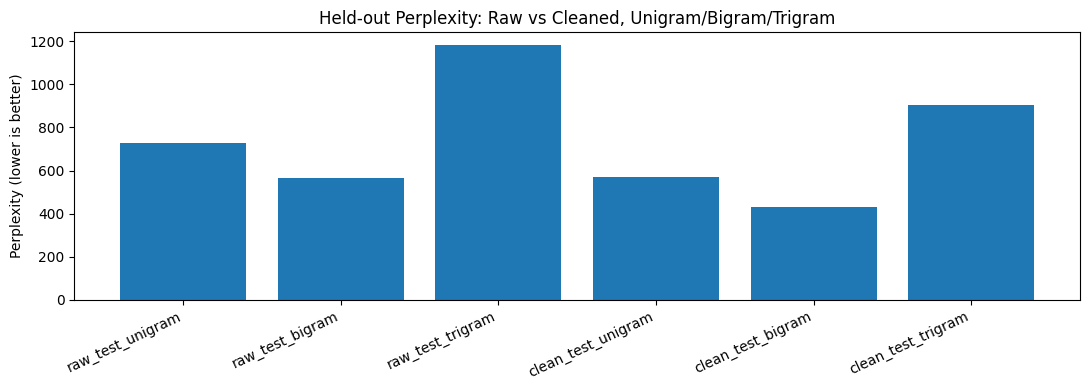

In [14]:
import matplotlib.pyplot as plt

# Held-out perplexity comparison (raw vs cleaned; unigram/bigram/trigram backoff)
perp_results = {
    'raw_test_unigram': perplexity(raw_test, raw_lm_model, 'unigram'),
    'raw_test_bigram': perplexity(raw_test, raw_lm_model, 'bigram'),
    'raw_test_trigram': perplexity(raw_test, raw_lm_model, 'trigram'),
    'clean_test_unigram': perplexity(clean_test, lm_model, 'unigram'),
    'clean_test_bigram': perplexity(clean_test, lm_model, 'bigram'),
    'clean_test_trigram': perplexity(clean_test, lm_model, 'trigram'),
}

print('Perplexity Summary (held-out test):')
print(f"Using k_unigram={K_UNIGRAM}, k_bigram={K_BIGRAM}, k_trigram={K_TRIGRAM}")
for k, v in perp_results.items():
    print(f"- {k}: {v:.2f}")

labels = list(perp_results.keys())
values = [perp_results[k] for k in labels]

plt.figure(figsize=(11, 4))
plt.bar(labels, values)
plt.xticks(rotation=25, ha='right')
plt.ylabel('Perplexity (lower is better)')
plt.title('Held-out Perplexity: Raw vs Cleaned, Unigram/Bigram/Trigram')
plt.tight_layout()
plt.savefig('perplexity_plot.png', dpi=200, bbox_inches='tight')
plt.show()
